# Customer Churn Analysis
Exploratory data analysis and predictive modeling on the Bank Customer Churn dataset.

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

sns.set_theme(style='whitegrid')
%matplotlib inline

## 2. Load Data

In [2]:
df = pd.read_csv('Churn_Modelling.csv')
print(df.shape)
df.head()

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3. Exploratory Data Analysis

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [4]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
print('Missing values:\n', df.isnull().sum())

Missing values:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


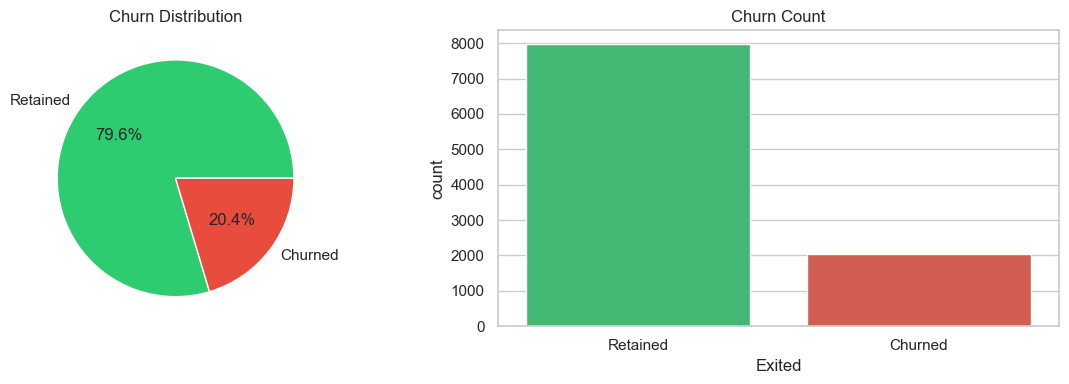

In [6]:
# Define numerical features (used throughout EDA)
num_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

# Churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df['Exited'].value_counts()
axes[0].pie(churn_counts, labels=['Retained', 'Churned'], autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Distribution')

sns.countplot(x='Exited', hue='Exited', data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[1], legend=False)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Retained', 'Churned'])
axes[1].set_title('Churn Count')

plt.tight_layout()
plt.show()

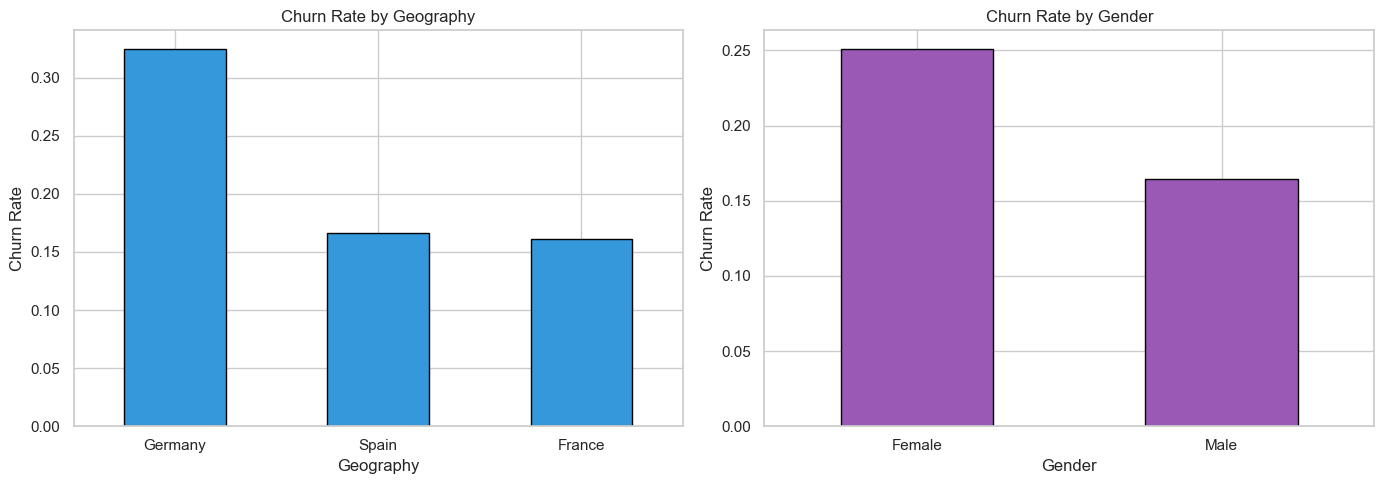

In [7]:
# Churn by Geography and Gender
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

geo_churn = df.groupby('Geography')['Exited'].mean().sort_values(ascending=False)
geo_churn.plot(kind='bar', ax=axes[0], color='#3498db', edgecolor='black')
axes[0].set_title('Churn Rate by Geography')
axes[0].set_ylabel('Churn Rate')
axes[0].tick_params(axis='x', rotation=0)

gender_churn = df.groupby('Gender')['Exited'].mean()
gender_churn.plot(kind='bar', ax=axes[1], color='#9b59b6', edgecolor='black')
axes[1].set_title('Churn Rate by Gender')
axes[1].set_ylabel('Churn Rate')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

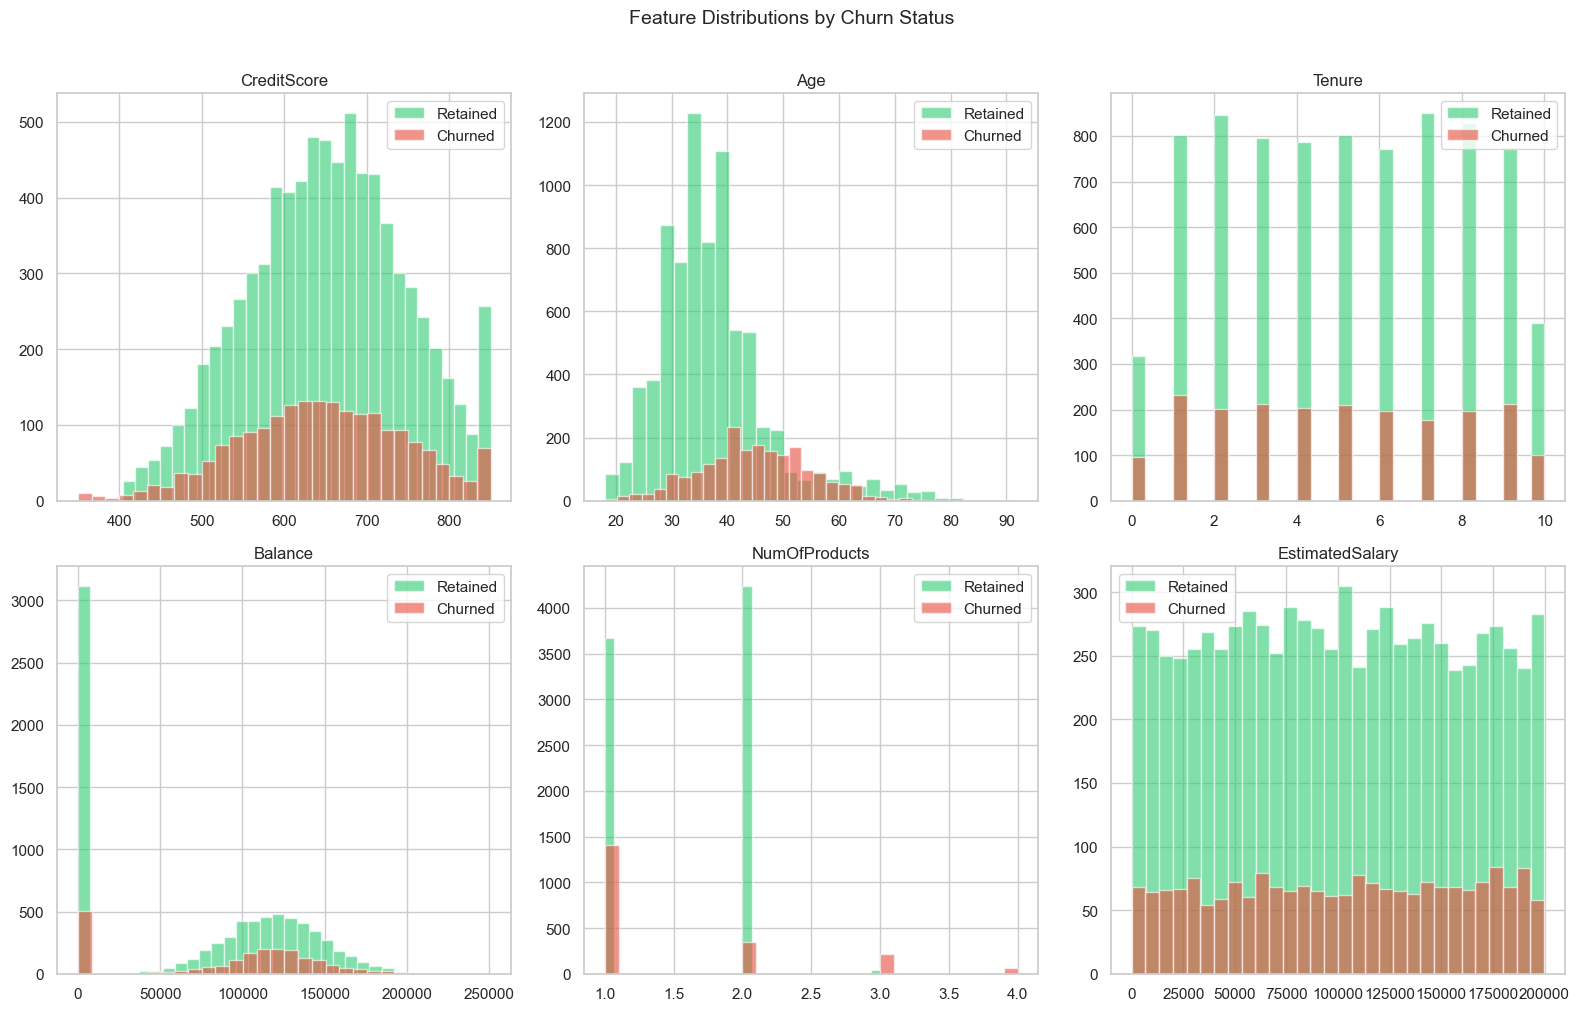

In [8]:
# Numerical feature distributions by churn
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    df[df['Exited'] == 0][col].hist(ax=axes[i], alpha=0.6, label='Retained', color='#2ecc71', bins=30)
    df[df['Exited'] == 1][col].hist(ax=axes[i], alpha=0.6, label='Churned', color='#e74c3c', bins=30)
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle('Feature Distributions by Churn Status', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

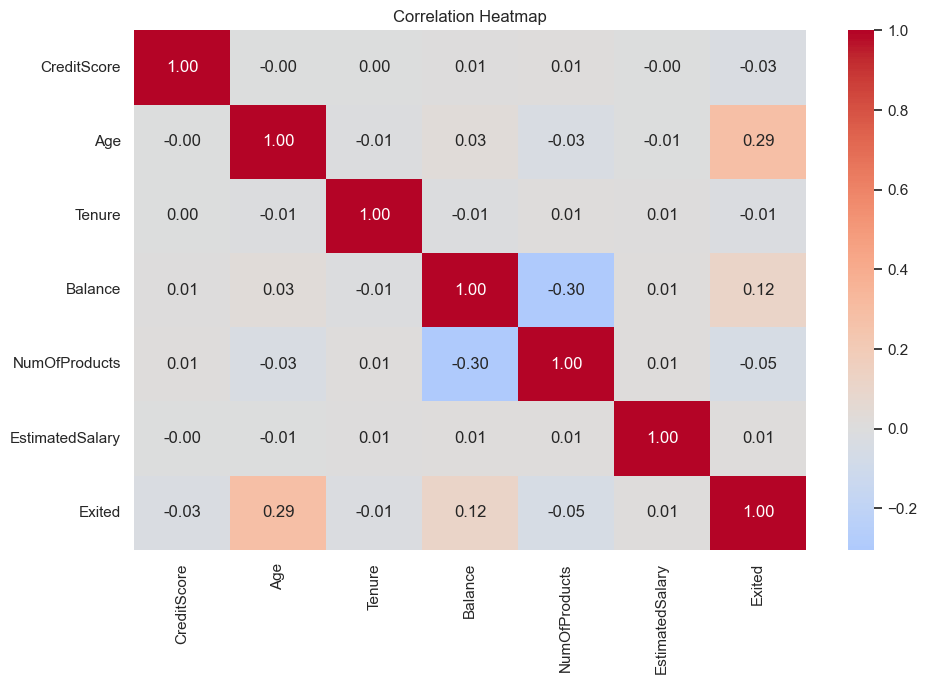

In [9]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr = df[num_features + ['Exited']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

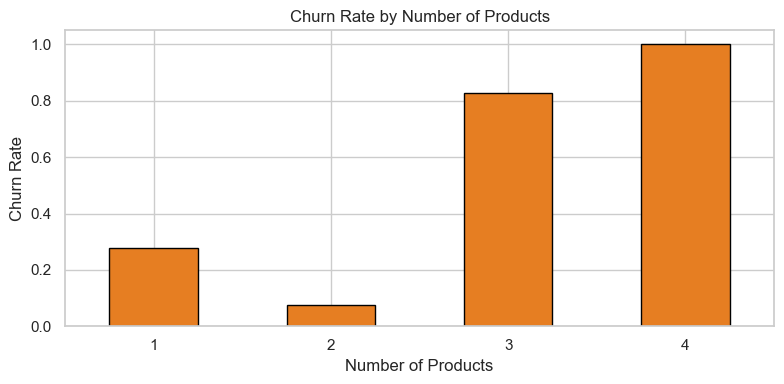

In [10]:
# Churn rate by number of products
plt.figure(figsize=(8, 4))
df.groupby('NumOfProducts')['Exited'].mean().plot(kind='bar', color='#e67e22', edgecolor='black')
plt.title('Churn Rate by Number of Products')
plt.ylabel('Churn Rate')
plt.xlabel('Number of Products')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Feature Engineering & Preprocessing

In [11]:
# Drop irrelevant columns
df_model = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# Encode categorical features
le = LabelEncoder()
df_model['Gender'] = le.fit_transform(df_model['Gender'])
df_model = pd.get_dummies(df_model, columns=['Geography'], drop_first=True)

X = df_model.drop(columns=['Exited'])
y = df_model['Exited']

print('Features:', X.columns.tolist())
print('Class distribution:\n', y.value_counts())

Features: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']
Class distribution:
 Exited
0    7963
1    2037
Name: count, dtype: int64


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Train size: 8000 | Test size: 2000


## 5. ANN Model Training & Evaluation

In [13]:
import tensorflow as tf

# Build ANN model
def build_ann(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(input_dim,)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

ann = build_ann(X_train_scaled.shape[1])
ann.summary()

/Users/khurshidalam/Documents/Customer Churn Predictor/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train ANN on training dataset
history = ann.fit(
    X_train_scaled, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    verbose=1
)

# Final epoch accuracy
print(f"\nFinal Train Accuracy : {history.history['accuracy'][-1]:.4f}")
print(f"Final Val   Accuracy : {history.history['val_accuracy'][-1]:.4f}")

Epoch 1/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 687us/step - accuracy: 0.7811 - loss: 0.5034 - val_accuracy: 0.8275 - val_loss: 0.4120
Epoch 2/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/step - accuracy: 0.8099 - loss: 0.4405 - val_accuracy: 0.8487 - val_loss: 0.3882
Epoch 3/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 413us/step - accuracy: 0.8253 - loss: 0.4182 - val_accuracy: 0.8562 - val_loss: 0.3601
Epoch 4/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 523us/step - accuracy: 0.8379 - loss: 0.3993 - val_accuracy: 0.8587 - val_loss: 0.3432
Epoch 5/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 416us/step - accuracy: 0.8393 - loss: 0.3884 - val_accuracy: 0.8662 - val_loss: 0.3318
Epoch 6/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 411us/step - accuracy: 0.8444 - loss: 0.3801 - val_accuracy: 0.8637 - val_loss: 0.3258
Epoch 7/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 444us/step - accuracy: 0.8439 - loss: 0.3782 - val_accuracy: 0.8637 - val_loss: 0.3289
Epoch 8/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 420us/step - accuracy: 0.8456 - loss: 0.3723 - 

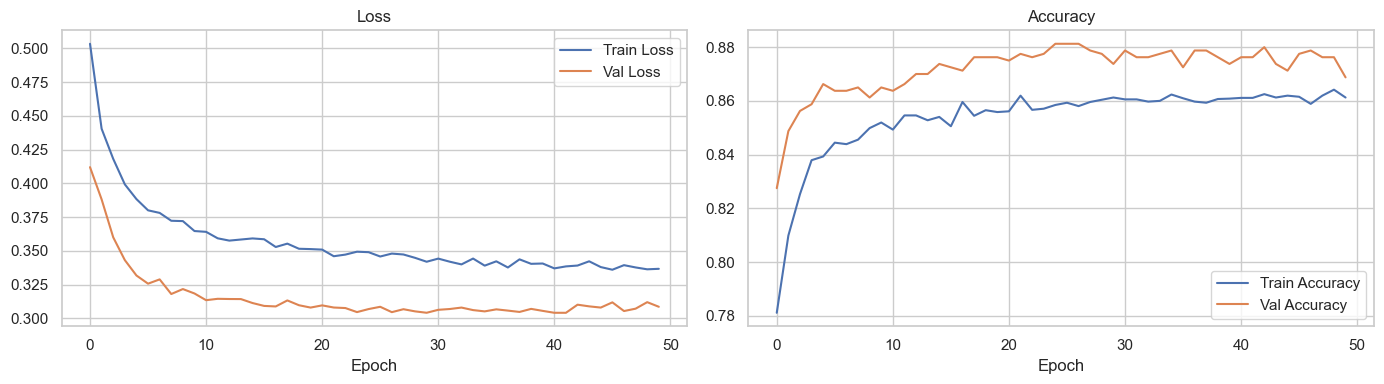

In [15]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
# Evaluate ANN on test set
y_pred_ann_prob = ann.predict(X_test_scaled).flatten()
y_pred_ann = (y_pred_ann_prob >= 0.5).astype(int)

print('=== ANN Classification Report ===')
print(classification_report(y_test, y_pred_ann, target_names=['Retained', 'Churned']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_pred_ann_prob):.4f}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 483us/step
=== ANN Classification Report ===
              precision    recall  f1-score   support

    Retained       0.87      0.97      0.92      1593
     Churned       0.81      0.44      0.57       407

    accuracy                           0.87      2000
   macro avg       0.84      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000

ROC-AUC: 0.8658


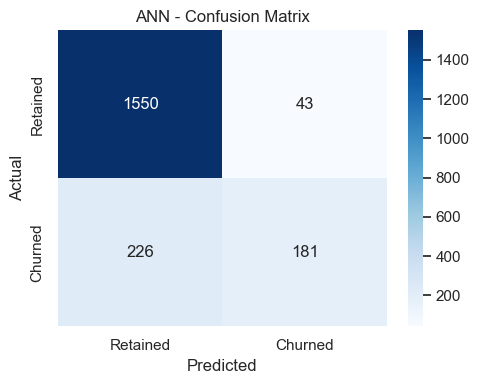

In [17]:
# Confusion matrix - ANN
cm_ann = confusion_matrix(y_test, y_pred_ann)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
plt.title('ANN - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

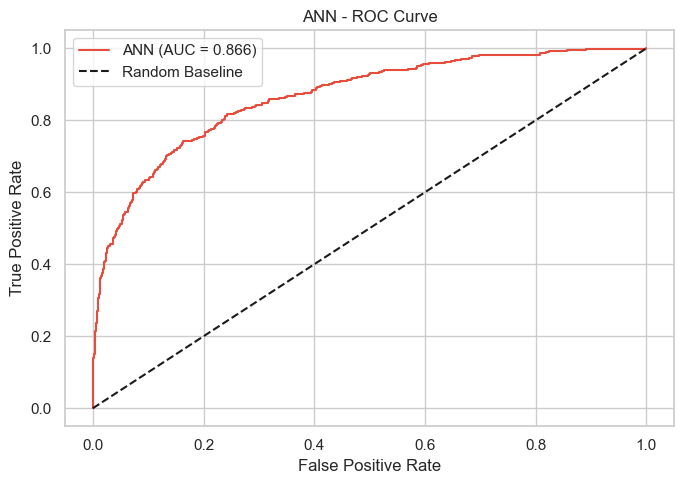

In [18]:
# ROC Curve - ANN only
fpr, tpr, _ = roc_curve(y_test, y_pred_ann_prob)
auc = roc_auc_score(y_test, y_pred_ann_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'ANN (AUC = {auc:.3f})', color='#e74c3c')
plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ANN - ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Key Insights

### Data & EDA Insights
- **Age** is the strongest predictor of churn — older customers churn more.
- **Germany** has a significantly higher churn rate compared to France and Spain.
- **Female** customers churn at a higher rate than male customers.
- Customers with **3-4 products** have very high churn rates.
- **Inactive members** are more likely to churn.
- **Balance** shows a bimodal distribution — customers with zero balance or very high balance tend to churn more.

### ANN Model Insights
- The ANN with two hidden layers (64 -> 32 neurons) and Dropout(0.3) effectively reduces overfitting.
- Training and validation accuracy curves converge smoothly, indicating good generalization.
- The ANN captures complex non-linear interactions between features that simpler models miss.
- Using **StandardScaler** on input features is critical for ANN convergence.
- The **sigmoid output** with a 0.5 threshold gives a balanced precision-recall trade-off; lowering the threshold can improve recall for churners at the cost of more false positives.